In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1. Quicklook data IHSG

In [45]:
data_ihsg = pd.read_json('data\Data IHSG.json')

df = pd.DataFrame(data_ihsg)

print(df.info(), "\n")
print(df.head(), "\n", df.tail())

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Asus VivoBook Go 14\AppData\Local\Temp\ipykernel_18552\2047834128.py:1: SyntaxWarning: invalid escape sequence '\D'
  data_ihsg = pd.read_json('data\Data IHSG.json')


<class 'pandas.DataFrame'>
RangeIndex: 239 entries, 0 to 238
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Tanggal     239 non-null    str    
 1   IHSG Close  239 non-null    float64
dtypes: float64(1), str(1)
memory usage: 3.9 KB
None 

      Tanggal   IHSG Close
0  2025-06-30  6927.679199
1  2025-07-01  6915.359863
2  2025-07-02  6881.245117
3  2025-07-03  6878.050781
4  2025-07-04  6865.191895 
         Tanggal   IHSG Close
234  2026-06-23  6101.333008
235  2026-06-24  5883.880859
236  2026-06-25  5999.038086
237  2026-06-26  5896.133789
238  2026-06-29  5820.790039


2. Quicklook dataset komentar

Proses ini saya gunakan untuk sinkronisasi tanggal dengan data komentar nya

In [46]:
data_komen = pd.read_csv('data\dataset komentar bersih.csv')

dfk = pd.DataFrame(data_komen)

print(dfk.head(), "\n\n", dfk.tail())

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Asus VivoBook Go 14\AppData\Local\Temp\ipykernel_18552\2207802362.py:1: SyntaxWarning: invalid escape sequence '\d'
  data_komen = pd.read_csv('data\dataset komentar bersih.csv')


      Tanggal                                           Komentar
0  2026-06-30  oalah bentar juga bubar srimulat x kud aja bub...
1  2026-06-30  Kopdes merah putih itu akan menghabisi pedagan...
2  2026-06-30  Tidak akan bertahan lama bangkrut besar pasak ...
3  2026-06-30  Kami yakin jadi bangunan mangkrak tiap kelurah...
4  2026-06-29                                            ABS😂😂😂😂 

          Tanggal                                           Komentar
2220  2026-06-19  Per unit Kdmp Nilai kontrak fisik 1.6 milyar D...
2221  2026-06-19  Lht saja 5 thn lg KDMP masih ada atau sdh jd F...
2222  2026-06-19                Wah asik nih Tumben ada ad 2 narsum
2223  2026-06-19   Jangan sampai KDKMP menjadi bancakan seperti BGN
2224  2026-06-19  sbnrnya kdmp ni penyelamat ekonomi desa atau p...


3. Slicing data IHSG dengan waktu yang sudah disingkronisasi

In [48]:
print(df.loc[231:238])

        Tanggal   IHSG Close
231  2026-06-18  6172.339844
232  2026-06-19  6177.139160
233  2026-06-22  6116.689941
234  2026-06-23  6101.333008
235  2026-06-24  5883.880859
236  2026-06-25  5999.038086
237  2026-06-26  5896.133789
238  2026-06-29  5820.790039


In [49]:
df_ihsg = df.loc[231:238]

In [50]:
print(df_ihsg.info())

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 231 to 238
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Tanggal     8 non-null      str    
 1   IHSG Close  8 non-null      float64
dtypes: float64(1), str(1)
memory usage: 260.0 bytes
None


4. Ubah tipe data

In [51]:
try:
    df_ihsg['Tanggal_format'] = pd.to_datetime(df_ihsg['Tanggal'], errors='coerce', dayfirst=True)
    print(df_ihsg.info())
except Exception as e:
    print(f"terjadi error saat format tanggal : {e}")

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 231 to 238
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Tanggal         8 non-null      str           
 1   IHSG Close      8 non-null      float64       
 2   Tanggal_format  8 non-null      datetime64[us]
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 324.0 bytes
None


C:\Users\Asus VivoBook Go 14\AppData\Local\Temp\ipykernel_18552\322060569.py:2: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_ihsg['Tanggal_format'] = pd.to_datetime(df_ihsg['Tanggal'], errors='coerce', dayfirst=True)


In [52]:
df_ihsg_bersih = df_ihsg[['Tanggal_format', 'IHSG Close']]
print(df_ihsg_bersih)

    Tanggal_format   IHSG Close
231     2026-06-18  6172.339844
232     2026-06-19  6177.139160
233     2026-06-22  6116.689941
234     2026-06-23  6101.333008
235     2026-06-24  5883.880859
236     2026-06-25  5999.038086
237     2026-06-26  5896.133789
238     2026-06-29  5820.790039


In [53]:
df_ihsg_bersih.reset_index(drop=True, inplace=True)
print(df_ihsg_bersih)

  Tanggal_format   IHSG Close
0     2026-06-18  6172.339844
1     2026-06-19  6177.139160
2     2026-06-22  6116.689941
3     2026-06-23  6101.333008
4     2026-06-24  5883.880859
5     2026-06-25  5999.038086
6     2026-06-26  5896.133789
7     2026-06-29  5820.790039


5. Visualisasi grafik pergerakan IHSG

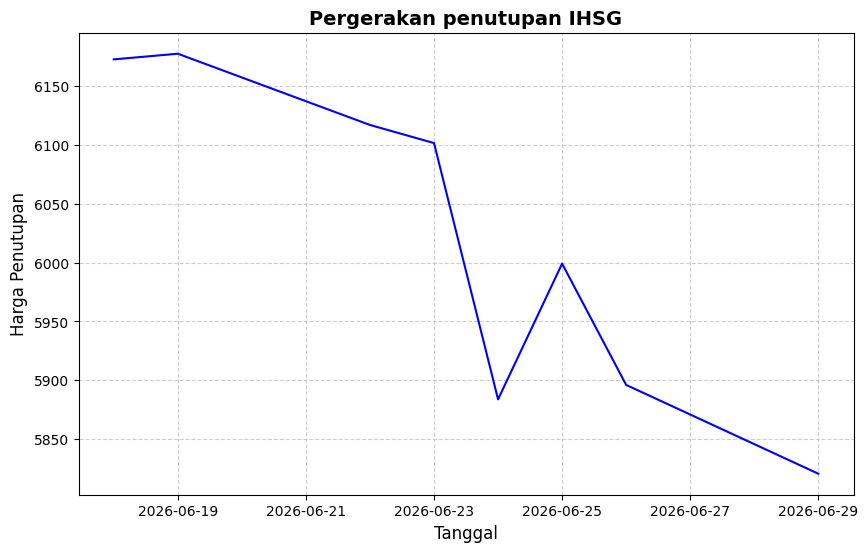

In [54]:
plt.figure(figsize=(10, 6))

plt.plot(df_ihsg_bersih['Tanggal_format'], df_ihsg_bersih['IHSG Close'], color='blue', linewidth=1.5)

plt.title("Pergerakan penutupan IHSG", fontsize=14, fontweight='bold')
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Harga Penutupan', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

6. Labeling nilai penutupan IHSG

0 = 'Lemah' <br>
1 = 'Kuat'

In [55]:
df_ihsg_bersih['Label'] = np.where(
    df_ihsg_bersih['IHSG Close'] > df_ihsg_bersih['IHSG Close'].shift(1),
    1,
    0
)

In [56]:
print(df_ihsg_bersih)

  Tanggal_format   IHSG Close  Label
0     2026-06-18  6172.339844      0
1     2026-06-19  6177.139160      1
2     2026-06-22  6116.689941      0
3     2026-06-23  6101.333008      0
4     2026-06-24  5883.880859      0
5     2026-06-25  5999.038086      1
6     2026-06-26  5896.133789      0
7     2026-06-29  5820.790039      0


In [58]:
df_ihsg_bersih.loc[1:7].to_csv('data/dataset IHSG (labeling).csv', index=False, encoding='utf-8')
print("dataset berhasil disimpan")

dataset berhasil disimpan
